<div style="
    direction: rtl;
    text-align: right;
    font-family: 'Vazirmatn', 'IRANSans', sans-serif;
    max-width: 760px;
    margin: 14px auto;
    padding: 16px 18px 16px 14px;
    border-radius: 18px;
    background: #ffffff;
    border: 1px solid #e5e7eb;
    border-right: 6px solid #2563eb;
    box-shadow: 0 6px 18px rgba(0, 0, 0, 0.045);
">
  <div style="margin-left: 18px;">
    <div style="
        display: inline-block;
        font-size: 11px;
        font-weight: 700;
        color: #1d4ed8;
        background: #eff6ff;
        padding: 4px 11px;
        border-radius: 999px;
        margin-bottom: 10px;
    ">
      دوره مبانی هوش مصنوعی
    </div>
    <div style="
        font-size: 24px;
        font-weight: 900;
        color: #111827;
        line-height: 1.4;
        margin-bottom: 6px;
    ">
      مبانی بینایی کامپیوتر | Computer Vision
    </div>
    <div style="
        width: 56px;
        height: 3px;
        background: linear-gradient(90deg, #2563eb, #60a5fa);
        border-radius: 999px;
        margin-bottom: 10px;
    "></div>
    <div style="
        font-size: 15px;
        font-weight: 700;
        color: #374151;
        margin-bottom: 4px;
    ">
      دبیرستان دوره اول علامه حلی ۵ تهران
    </div>
    <div style="
        font-size: 14px;
        color: #4b5563;
        line-height: 1.7;
        margin-bottom: 10px;
    ">
    <span style="font-weight: 700; color: #111827;">پارسا صدری</span> و <span style="font-weight: 700; color: #111827;">علیرضا سپهری</span>
    </div>
    <div style="
        display: inline-block;
        font-size: 12px;
        color: #1e40af;
        background: #f0f9ff;
        padding: 4px 10px;
        border-radius: 999px;
        border: 1px solid #bae6fd;
    ">
      تابستان ۱۴۰۵
    </div>
  </div>
</div>


# آشنایی با بینایی ماشین

در این جلسه می‌خواهیم ببینیم کامپیوتر چگونه تصاویر را می‌بیند و از آن‌ها اطلاعات به دست می‌آورد.

ما در این مسیر یاد می‌گیریم:

- تصویر از چه چیزی ساخته شده است؟
- پیکسل و رنگ‌های RGB چه هستند؟
- چگونه یک تصویر رنگی را خاکستری کنیم؟
- کامپیوتر چگونه لبه‌ها و مرز اشیا را پیدا می‌کند؟
- چگونه می‌توانیم اشیای قرمز را در یک تصویر پیدا کنیم؟
- چگونه یک مدل آماده، چهره‌ها را در تصویر تشخیص می‌دهد؟

> کامپیوتر در ابتدا تصویر را مثل انسان نمی‌بیند؛ بلکه آن را به شکل مجموعه‌ای از عددها دریافت می‌کند.

از کتابخانه `opencv` برای پروژه های بینایی کامپیوتر استفاده می شود.

In [1]:
# pip install opencv-python
import cv2
import matplotlib.pyplot as plt
import numpy as np

## 1) تصویر چیست؟

ما وقتی به یک عکس نگاه می‌کنیم، ممکن است در آن یک انسان، حیوان یا ماشین ببینیم.

اما کامپیوتر در اولین مرحله چنین مفاهیمی را نمی‌بیند. برای کامپیوتر، تصویر مجموعه‌ای بزرگ از عددهاست.

هر تصویر دیجیتال از مربع‌های بسیار کوچکی ساخته شده است. به هر مربع کوچک، **پیکسل** می‌گوییم.

هرچه تعداد پیکسل‌ها بیشتر باشد، معمولاً تصویر جزئیات بیشتری دارد.

در این بخش تصویر را وارد می‌کنیم و آن را روی صفحه نمایش می‌دهیم.

ابعاد تصویر: (554, 554, 3)


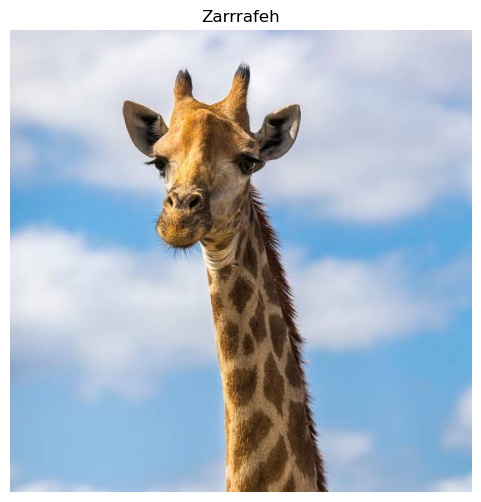

مقدار رنگ پیکسل در نقطه (100,100): [224 227 234]


In [2]:
img = cv2.imread('assets/zarrrafeh.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"ابعاد تصویر: {img.shape}")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title("Zarrrafeh")
plt.show()

print("مقدار رنگ پیکسل در نقطه (100,100):", img[100, 100])

## 2) پیکسل و رنگ RGB

در یک تصویر رنگی، هر پیکسل معمولاً با سه عدد توصیف می‌شود.

این سه عدد مربوط به سه رنگ اصلی هستند:

- `R`: مقدار قرمز یا Red
- `G`: مقدار سبز یا Green
- `B`: مقدار آبی یا Blue

به این روش نمایش رنگ، **RGB** می‌گوییم.

مقدار هر رنگ معمولاً بین `0` تا `255` است:

- `0` یعنی نبودن آن رنگ
- `255` یعنی بیشترین مقدار آن رنگ

برای مثال:
```python
[255, 0, 0]

[0, 255, 0]      # سبز
[0, 0, 255]      # آبی
[0, 0, 0]        # سیاه
[255, 255, 255]  # سفید

## 3) بزرگ‌نمایی پیکسل‌ها

پیکسل‌ها در یک تصویر معمولی آن‌قدر کوچک هستند که با چشم دیده نمی‌شوند.

اگر بخشی از تصویر را بزرگ کنیم، می‌توانیم ساختار مربعی پیکسل‌ها را بهتر ببینیم.

هر پیکسل یک موقعیت در تصویر دارد و مقدارهای رنگی مخصوص خودش را نگه می‌دارد.

پس می‌توانیم تصویر را مانند یک جدول بزرگ تصور کنیم:

- ردیف‌ها، موقعیت عمودی پیکسل‌ها هستند.
- ستون‌ها، موقعیت افقی پیکسل‌ها هستند.
- مقدار هر خانه، رنگ آن پیکسل را مشخص می‌کند.

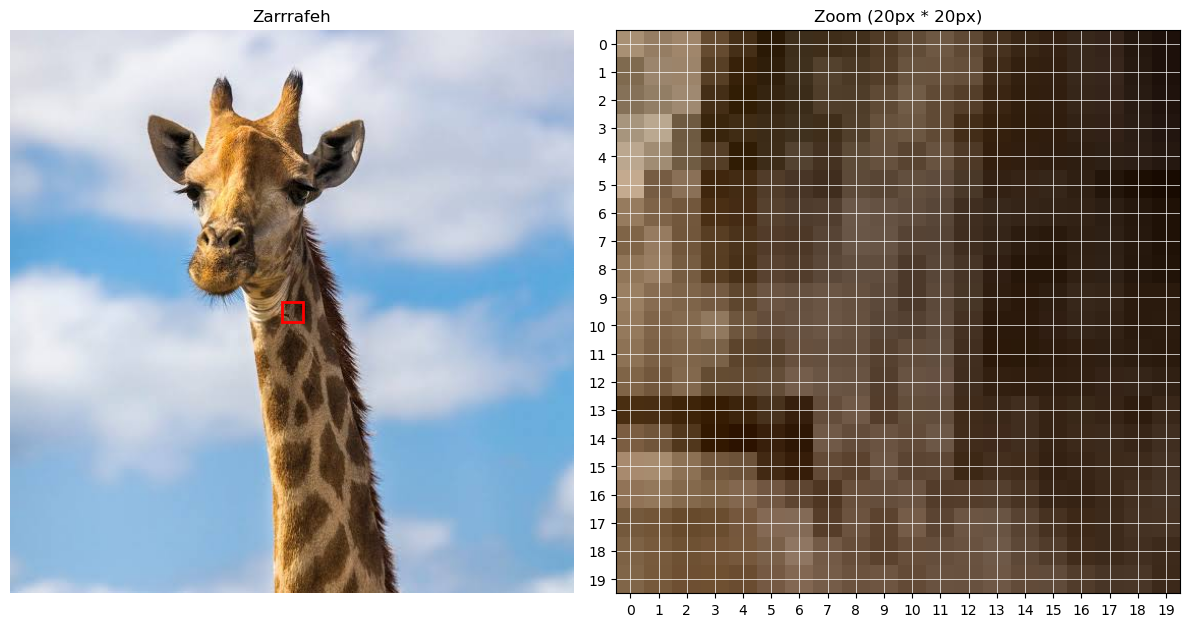

In [3]:
import cv2
import matplotlib.pyplot as plt

img_bgr = cv2.imread('assets/zarrrafeh.jpg')

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

height, width, _ = img.shape
center_y, center_x = height // 2, width // 2

size = 10
cropped_area = img[center_y - size : center_y + size, center_x - size : center_x + size]
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
rect = plt.Rectangle((center_x - size, center_y - size), size*2, size*2, edgecolor='red', facecolor='none', linewidth=2)
plt.gca().add_patch(rect)
plt.title("Zarrrafeh")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cropped_area, interpolation='nearest')
plt.title("Zoom (20px * 20px)")

plt.grid(color='white', linestyle='-', linewidth=0.5)
plt.xticks(range(size*2))
plt.yticks(range(size*2))
plt.tight_layout()
plt.show()

## 4) تبدیل تصویر رنگی به خاکستری

در تصویر رنگی، هر پیکسل با سه مقدار رنگی توصیف می‌شود.

اما در تصویر خاکستری، برای هر پیکسل فقط یک مقدار روشنایی داریم:

- مقدار نزدیک به `0`: تیره یا سیاه
- مقدار نزدیک به `255`: روشن یا سفید
- مقدارهای بین این دو: طیف‌های مختلف خاکستری

با تبدیل تصویر به خاکستری، اطلاعات مربوط به رنگ حذف می‌شود؛ اما شکل کلی و بسیاری از جزئیات تصویر باقی می‌ماند.

این کار در بسیاری از پروژه‌های بینایی ماشین مفید است، چون پردازش یک مقدار برای هر پیکسل ساده‌تر از پردازش سه مقدار است.

در خروجی زیر، تصویر رنگی و همان تصویر در حالت خاکستری را با هم مقایسه می‌کنیم.

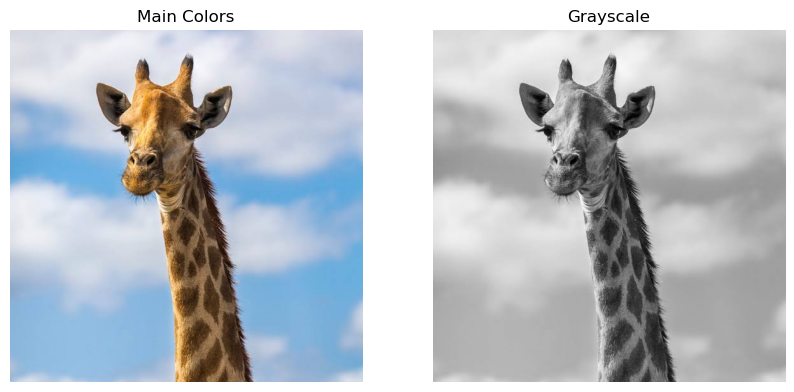

In [4]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Main Colors")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.show()

## 5) مات یا محو کردن تصویر

گاهی یک تصویر دارای نویز است؛ یعنی نقاط یا تغییرات کوچک و ناخواسته‌ای در آن دیده می‌شود.

برای کاهش این نویزها می‌توانیم تصویر را کمی مات یا محو کنیم. به این کار **Blur** می‌گوییم.

در این مرحله، هر پیکسل با توجه به پیکسل‌های اطرافش کمی تغییر می‌کند. در نتیجه تغییرات خیلی کوچک کمتر دیده می‌شوند.

Blur می‌تواند به کامپیوتر کمک کند تا به جای توجه به جزئیات بی‌اهمیت، شکل‌های اصلی تصویر را بهتر بررسی کند.

البته اگر تصویر را بیش از حد مات کنیم، جزئیات مهم آن نیز از بین می‌روند.

## 6) تشخیص لبه‌ها

لبه یا Edge، قسمتی از تصویر است که در آن رنگ یا روشنایی به‌سرعت تغییر می‌کند.

برای مثال، مرز بین یک جسم و پس‌زمینه معمولاً یک لبه است.

انسان‌ها با نگاه کردن به لبه‌ها می‌توانند شکل اشیا را تشخیص دهند. کامپیوتر نیز می‌تواند با بررسی تغییرات روشنایی، بعضی از این لبه‌ها را پیدا کند.

در این بخش از روش **Canny** استفاده می‌کنیم.

خروجی معمولاً شبیه یک نقاشی دورخطی است:

- قسمت‌های سفید، لبه‌های پیدا شده هستند.
- قسمت‌های سیاه، بخش‌هایی هستند که لبهٔ مشخصی در آن‌ها پیدا نشده است.

> تشخیص لبه به معنی فهم کامل تصویر نیست؛ فقط مرزها و تغییرات مهم تصویر را پیدا می‌کند.

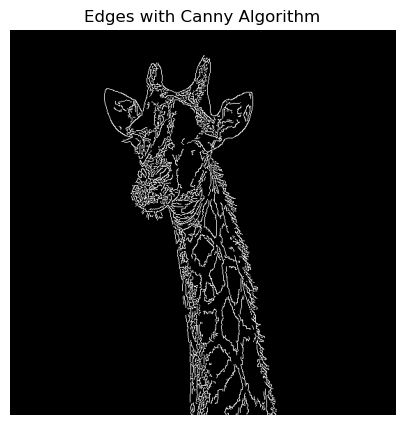

In [5]:
edges = cv2.Canny(gray_img, 100, 200)

plt.figure(figsize=(10,5))
plt.imshow(edges, cmap='gray')
plt.title("Edges with Canny Algorithm")
plt.axis('off')
plt.show()

## 7) پیدا کردن اشیای قرمز

حالا می‌خواهیم یک قانون ساده برای کامپیوتر تعریف کنیم:

> هر پیکسلی که قرمز است پیدا کن و بقیهٔ پیکسل‌ها را کنار بگذار.

برای این کار ابتدا تصویر را به فضای رنگی **HSV** تبدیل می‌کنیم.

در HSV:

- `H` یا Hue نوع رنگ را مشخص می‌کند؛ مثلاً قرمز یا آبی
- `S` یا Saturation میزان خلوص و شدت رنگ را مشخص می‌کند
- `V` یا Value میزان روشنایی رنگ را مشخص می‌کند

برای تشخیص قرمز، محدوده‌ای از این سه مقدار تعریف می‌کنیم.

در OpenCV، رنگ قرمز در دو بخش از محدودهٔ Hue قرار دارد. به همین دلیل دو ماسک می‌سازیم و سپس آن‌ها را با هم ترکیب می‌کنیم.

ماسک مانند یک فیلتر سیاه‌وسفید است:

- سفید: پیکسلی که احتمالاً قرمز است
- سیاه: پیکسلی که قرمز نیست

در پایان، ماسک را روی تصویر اصلی اعمال می‌کنیم تا فقط قسمت‌های قرمز باقی بمانند.

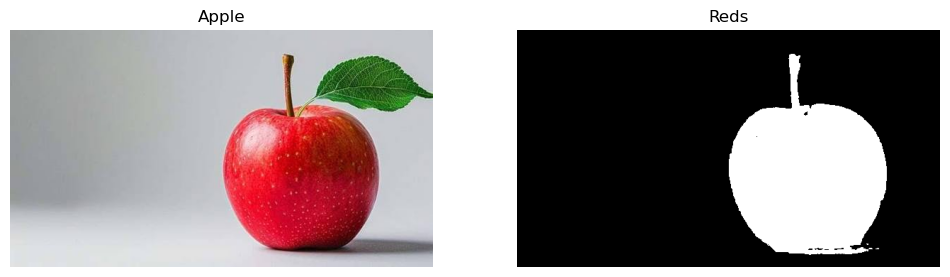

In [6]:
red_img = cv2.imread('assets/apple.jpg')
red_img = cv2.cvtColor(red_img, cv2.COLOR_BGR2RGB)
hsv_img = cv2.cvtColor(red_img, cv2.COLOR_RGB2HSV)

lower_red_1 = np.array([0, 30, 20])
upper_red_1 = np.array([20, 255, 255])

lower_red_2 = np.array([165, 30, 20])
upper_red_2 = np.array([179, 255, 255])

mask_1 = cv2.inRange(hsv_img, lower_red_1, upper_red_1)
mask_2 = cv2.inRange(hsv_img, lower_red_2, upper_red_2)

mask = cv2.bitwise_or(mask_1, mask_2)

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.imshow(red_img)
plt.title("Apple")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Reds")
plt.axis('off')
plt.show()

### چرا برای قرمز دو بازه داریم؟

در فضای HSV، رنگ قرمز در نزدیکی ابتدای محدوده و همچنین نزدیکی انتهای محدودهٔ Hue قرار دارد.

بنابراین فقط یک بازه ممکن است بعضی از قرمزها را پیدا نکند.

برای پوشش قرمزهای بیشتر، دو بازه تعریف می‌کنیم:

- بازهٔ اول: قرمزهای نزدیک به ابتدای Hue
- بازهٔ دوم: قرمزهای نزدیک به انتهای Hue

سپس با استفاده از عملگر `OR` هر دو نتیجه را با هم ترکیب می‌کنیم.

یعنی:

> اگر یک پیکسل در بازهٔ اول قرمز بود یا در بازهٔ دوم قرمز بود، آن را به عنوان پیکسل قرمز نگه دار.

## 8) تمیز کردن نتیجه

گاهی در ماسک قرمز، نقاط کوچک و اضافی دیده می‌شود. این نقاط ممکن است به دلیل نور، سایه یا رنگ‌های مشابه ایجاد شده باشند.

برای بهتر کردن نتیجه، ماسک را کمی تمیز می‌کنیم:

- نقاط کوچک و جداشده را حذف می‌کنیم.
- سوراخ‌های کوچک داخل ناحیه‌های قرمز را تا حدی پر می‌کنیم.

این مرحله باعث می‌شود قسمت‌های قرمز تصویر منظم‌تر و واضح‌تر دیده شوند.

توجه کنید که این عملیات تصویر اصلی را تغییر نمی‌دهد؛ فقط ماسکی را که برای جدا کردن رنگ ساخته‌ایم، اصلاح می‌کند.

## 9) تشخیص چهره با یک مدل آماده

در این بخش از یک مدل از قبل آماده‌شده برای پیدا کردن چهره استفاده می‌کنیم.

این مدل قبلاً با نمونه‌های زیادی از چهره‌ها ساخته شده است. ما در این جلسه مدل را از ابتدا آموزش نمی‌دهیم؛ فقط از آن برای تشخیص چهره در یک تصویر استفاده می‌کنیم.

مدل معمولاً محل احتمالی چهره را با یک مستطیل مشخص می‌کند.

تفاوت دو مفهوم مهم:

- **تشخیص چهره یا Face Detection:** پیدا کردن محل چهره در تصویر
- **شناسایی چهره یا Face Recognition:** تشخیص اینکه چهره متعلق به چه کسی است

کدی که در این بخش استفاده می‌کنیم فقط محل چهره را پیدا می‌کند و نمی‌گوید این شخص چه کسی است.

> مدل ممکن است همیشه درست عمل نکند؛ نور، زاویهٔ صورت، کیفیت تصویر و اندازهٔ چهره روی نتیجه اثر می‌گذارند.

## 10) تفاوت پردازش تصویر و بینایی ماشین

در این جلسه چند کار مختلف روی تصویر انجام دادیم.

### پردازش تصویر

در پردازش تصویر، خود تصویر را تغییر می‌دهیم یا ویژگی‌های آن را بهتر استخراج می‌کنیم.

نمونه‌ها:

- تبدیل تصویر رنگی به خاکستری
- مات کردن تصویر
- پیدا کردن لبه‌ها
- جدا کردن یک رنگ خاص

### بینایی ماشین

در بینایی ماشین، هدف این است که کامپیوتر از تصویر اطلاعاتی به دست آورد.

نمونه‌ها:

- پیدا کردن چهره
- تشخیص خودرو
- شمارش اشیا
- خواندن پلاک
- تشخیص بیماری در تصویر پزشکی

پردازش تصویر می‌تواند یکی از مراحل آماده‌سازی برای بینایی ماشین باشد.

In [7]:
from IPython.display import HTML

HTML("""
<style>
.jp-RenderedMarkdown, 
.rendered_html, 
.jp-MarkdownOutput {
    direction: rtl !important;
    text-align: right !important;
    font-family: "Vazirmatn", "Vazir", sans-serif !important;
    line-height: 1.8 !important;
}
.jp-RenderedMarkdown p, 
.jp-RenderedMarkdown li, 
.jp-RenderedMarkdown h1, 
.jp-RenderedMarkdown h2, 
.jp-RenderedMarkdown h3, 
.jp-RenderedMarkdown h4, 
.jp-RenderedMarkdown div,
.rendered_html p, 
.rendered_html li, 
.rendered_html h1, 
.rendered_html h2, 
.rendered_html h3 {
    direction: rtl !important;
    text-align: right !important;
    font-family: "Vazirmatn", "Vazir", sans-serif !important;
}
.jp-RenderedMarkdown ul, 
.jp-RenderedMarkdown ol,
.rendered_html ul, 
.rendered_html ol {
    padding-right: 2em !important;
    padding-left: 0 !important;
}
</style>
""")